In [4]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [6]:
DATA = Path("../data")

In [7]:
print(DATA)

..\data


In [8]:
df = pd.read_csv(DATA / 'loan_data.csv')

In [9]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [12]:
print("Rows :", df.shape[0])

Rows : 614


In [13]:
print("Columns: ", df.shape[1])

Columns:  13


# Data exploration

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


## Lets look at missing values

In [15]:
missing = df.isnull().sum()

print(missing)

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


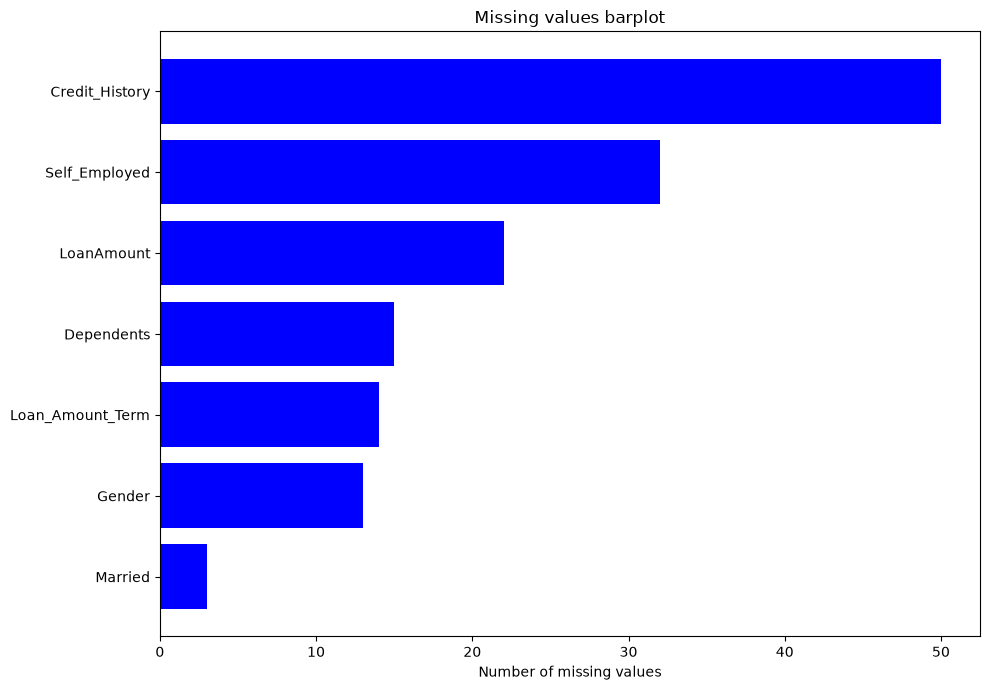

In [17]:
missing = missing[missing > 0].sort_values()

plt.figure(figsize=(10,7))
plt.barh(missing.index, missing, color = 'blue')
plt.title("Missing values barplot")
plt.xlabel("Number of missing values")
plt.tight_layout()
plt.show()

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


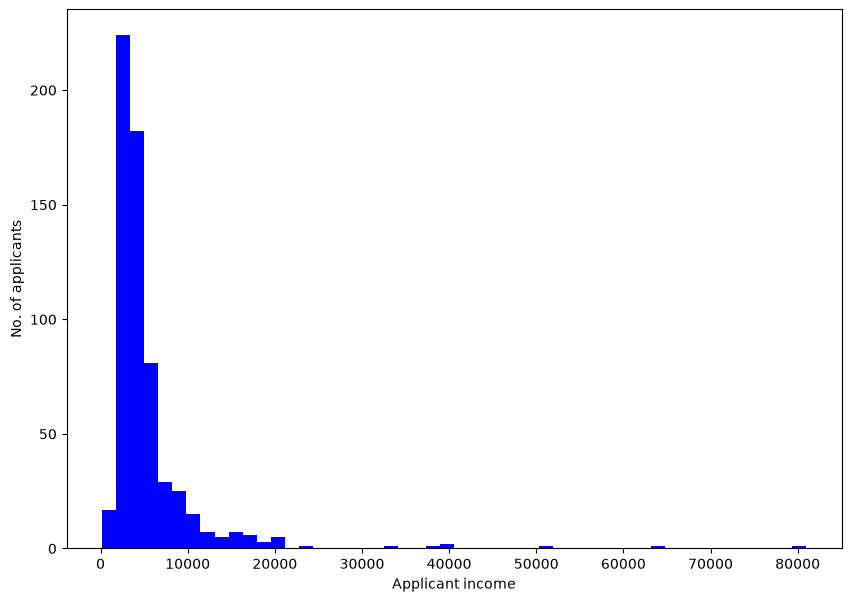

In [21]:
plt.figure(figsize=(10,7))
plt.hist(df['ApplicantIncome'], bins=50, color='blue')
plt.xlabel("Applicant income")
plt.ylabel("No. of applicants")
plt.show()

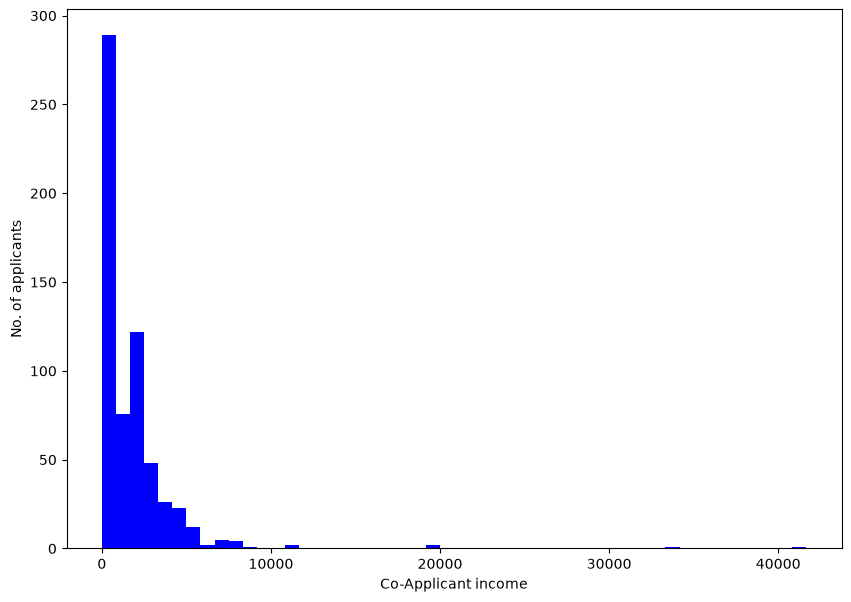

In [22]:
plt.figure(figsize=(10,7))
plt.hist(df['CoapplicantIncome'], bins=50, color='blue')
plt.xlabel("Co-Applicant income")
plt.ylabel("No. of applicants")
plt.show()

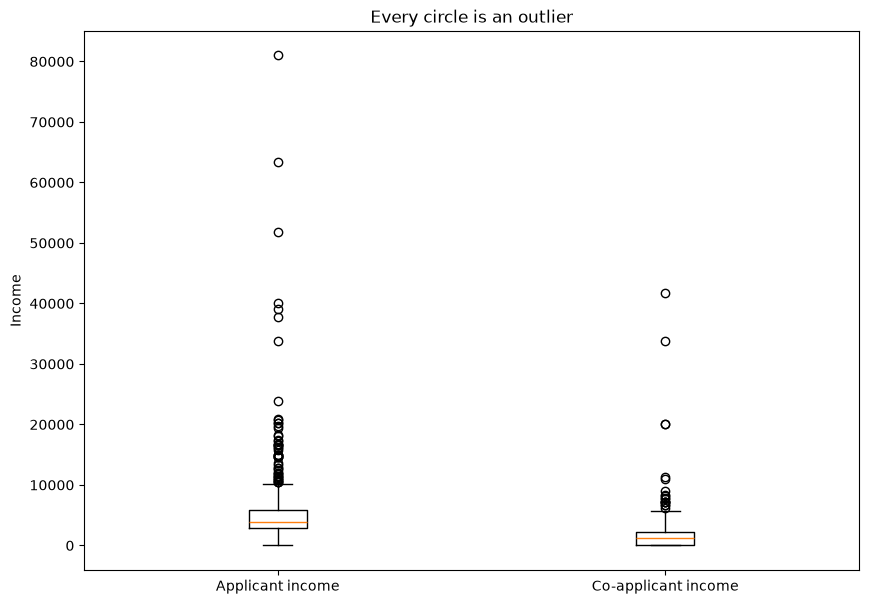

In [23]:
plt.figure(figsize=(10,7))
plt.boxplot([df['ApplicantIncome'], df['CoapplicantIncome']])
plt.xticks([1,2], ['Applicant income', 'Co-applicant income'])
plt.title("Every circle is an outlier")
plt.ylabel("Income")
plt.show()

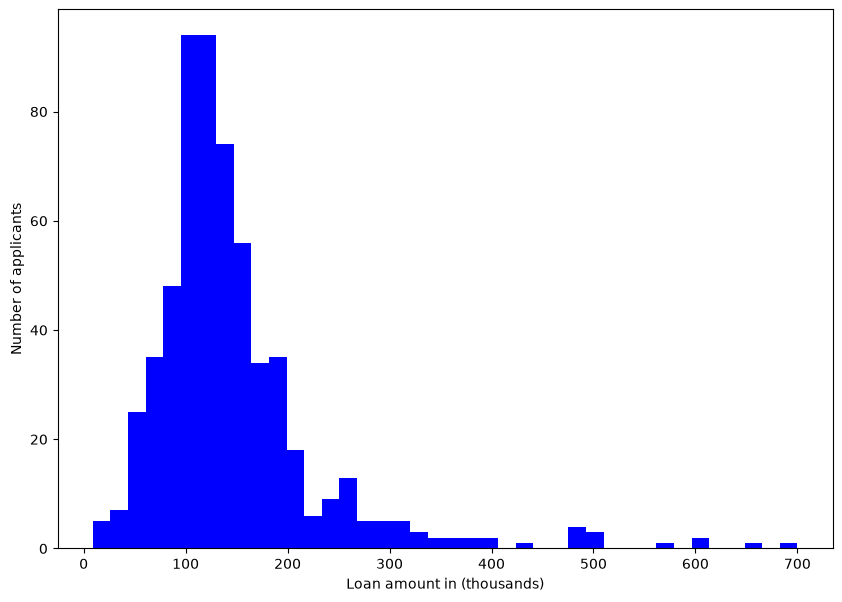

In [26]:
plt.figure(figsize=(10,7))
plt.hist(df['LoanAmount'].dropna(), bins = 40, color = 'blue')
plt.xlabel("Loan amount in (thousands)")
plt.ylabel("Number of applicants")
plt.show()

In [28]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

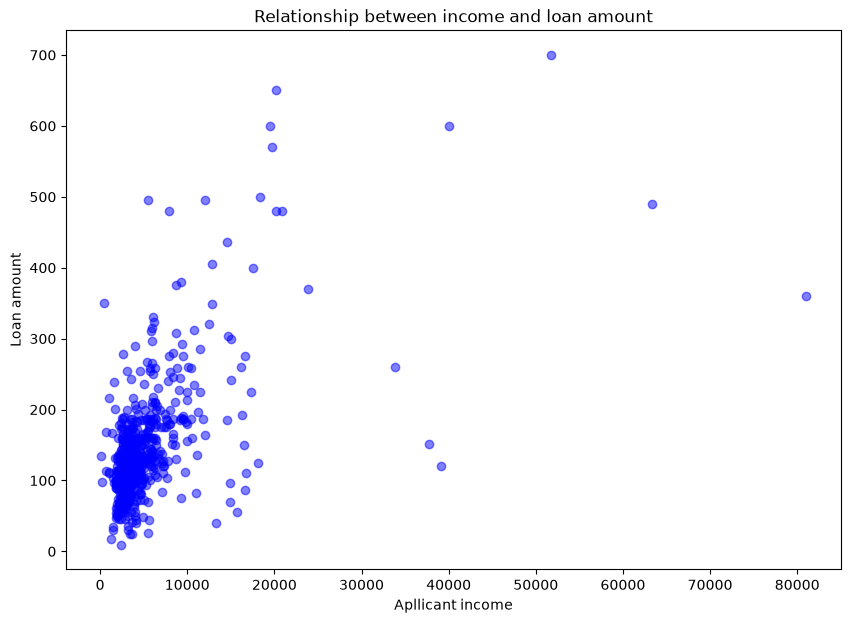

In [29]:
plt.figure(figsize=(10,7))
plt.scatter(df['ApplicantIncome'], df['LoanAmount'], color= 'blue', alpha = 0.5)
plt.title("Relationship between income and loan amount")
plt.xlabel("Apllicant income")
plt.ylabel("Loan amount")
plt.show()

In [31]:
counts = df['Loan_Status'].value_counts()

print(counts)

Loan_Status
Y    422
N    192
Name: count, dtype: int64


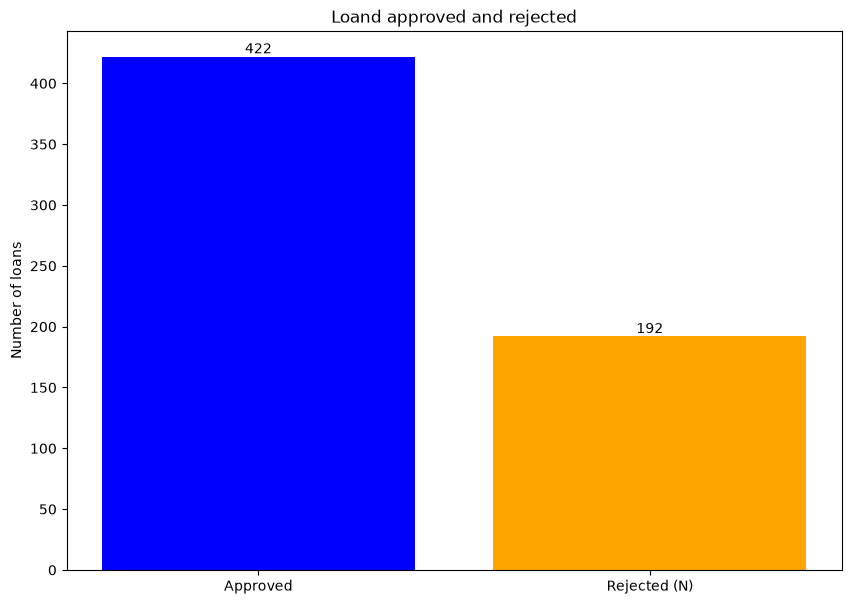

In [32]:
plt.figure(figsize=(10,7))
bars = plt.bar(['Approved', 'Rejected (N)'], counts, color=['blue', 'orange'])
plt.bar_label(bars)
plt.title("Loand approved and rejected")
plt.ylabel("Number of loans")
plt.show()

In [ ]:
df['Approved'] = df['Loan_Status'].map({"Y": 1, "N": 0})


print(df.groupby('Credit_History')['Approved'].mean())


Credit_History
0.0    0.078652
1.0    0.795789
Name: Approved, dtype: float64


In [37]:
print(df.groupby('Property_Area')['Approved'].mean())

Property_Area
Rural        0.614525
Semiurban    0.768240
Urban        0.658416
Name: Approved, dtype: float64


In [38]:
print(df.groupby('Education')['Approved'].mean())

Education
Graduate        0.708333
Not Graduate    0.611940
Name: Approved, dtype: float64


In [40]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

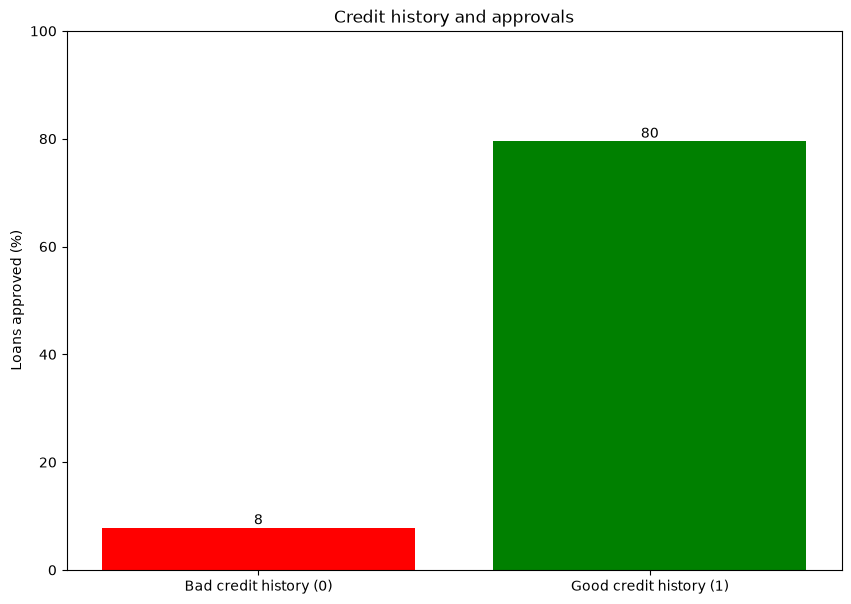

In [41]:
## plotting approval rate based on the credit history

rate = df.groupby('Credit_History')['Approved'].mean() * 100

labels = ['Bad credit history (0)', 'Good credit history (1)']

plt.figure(figsize=(10,7))
bars = plt.bar(labels, rate, color = ['red', 'green'])
plt.bar_label(bars, fmt = "%.0f")
plt.title("Credit history and approvals")
plt.ylabel("Loans approved (%)")
plt.ylim(0,100)
plt.show()

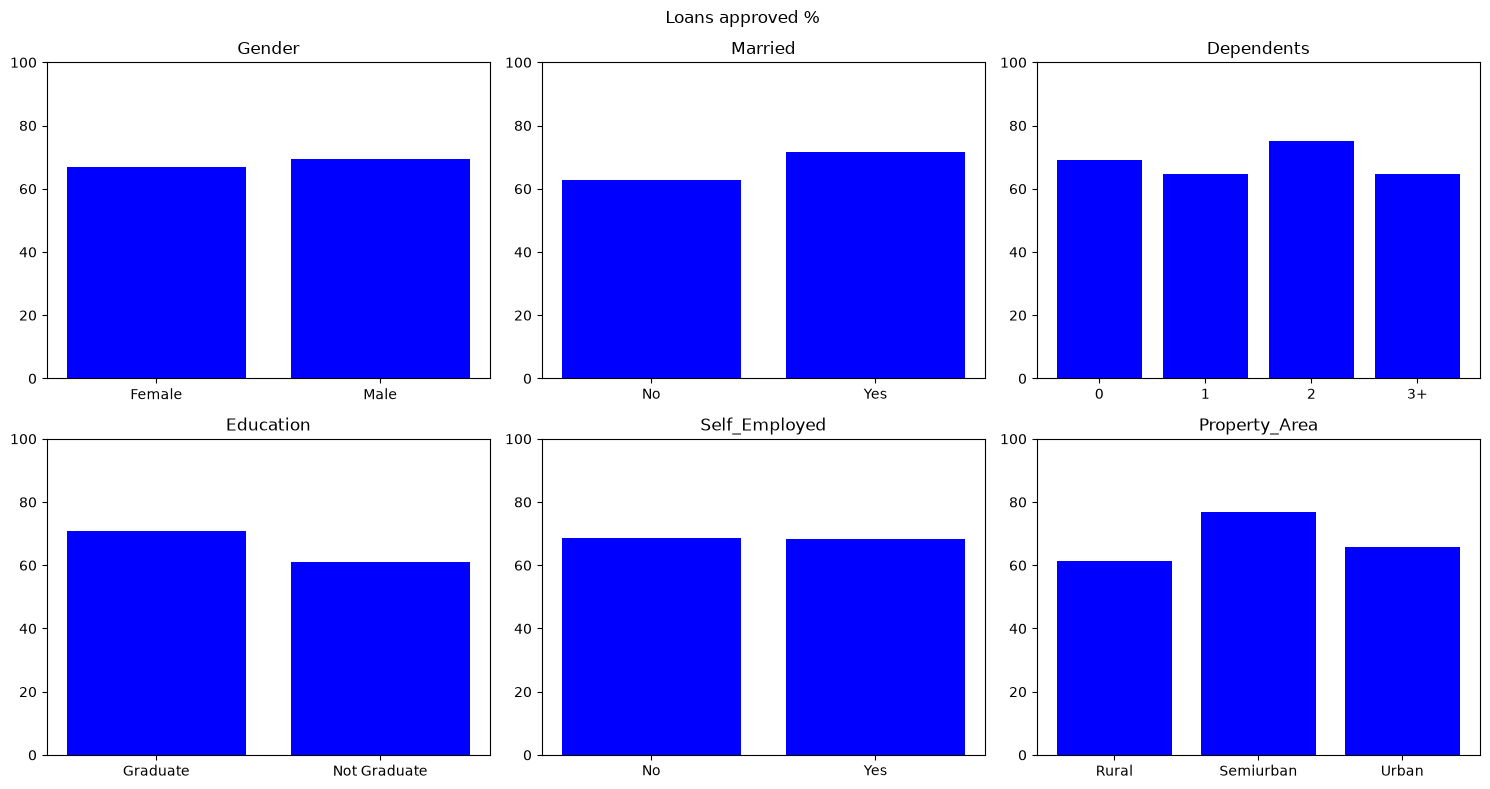

In [49]:
## Plot approval rate based on all the categories

columns = ['Gender', 'Married', 'Dependents',
           'Education', 'Self_Employed', 'Property_Area']

plt.figure(figsize=(15,8))
for i, column in enumerate(columns):
    rate = df.groupby(column)['Approved'].mean() * 100
    plt.subplot(2, 3, i + 1)
    plt.bar(rate.index, rate, color = 'blue')
    plt.title(column)
    plt.ylim(0, 100)
plt.suptitle("Loans approved % ")
plt.tight_layout()
plt.show()

pandas.Series